# Experimental EMD Images

Load every EMD file with pyTEMlib, print the acquisition details, normalize the HAADF image, and plot the complete dataset.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyTEMlib.file_tools as ft

root_path = Path.cwd().resolve()
if not (root_path / 'experimental_data').is_dir():
    root_path = root_path.parent

files = sorted((root_path / 'experimental_data').glob('*.emd'))
if not files:
    raise FileNotFoundError('No EMD files found in experimental_data')

print(f'Found {len(files)} EMD files')

Found 4 EMD files


In [3]:
images = []
for path in files:
    haadf = ft.open_file(str(path))['Channel_000']
    pixel_size_nm = float(haadf.original_metadata['BinaryResult']['PixelSize']['width']) * 1e9
    frame_time = float(haadf.original_metadata['Scan']['FrameTime'])

    haadf -= haadf.min()
    haadf /= haadf.max()
    images.append((path, haadf, pixel_size_nm, frame_time))

    print(
        f'{path.name}: {haadf.shape[1]} x {haadf.shape[0]} px, '
        f'{pixel_size_nm:.5f} nm/px, frame time {frame_time:.5f} s'
    )

0042 - 20250226 6.10 Mx STEM HAADF Diffraction 16.4 nm.emd: 1024 x 1024 px, 0.01601 nm/px, frame time 22.58944 s
0050 - STEM Nano Diffraction HAADF 12.0 Mx 8.2 nm.emd: 1024 x 1024 px, 0.00801 nm/px, frame time 22.58944 s
0052 - STEM Nano Diffraction HAADF 3.00 Mx 32.8 nm.emd: 2048 x 2048 px, 0.01601 nm/px, frame time 87.81824 s
WS2.emd: 1024 x 1024 px, 0.01062 nm/px, frame time 22.58944 s


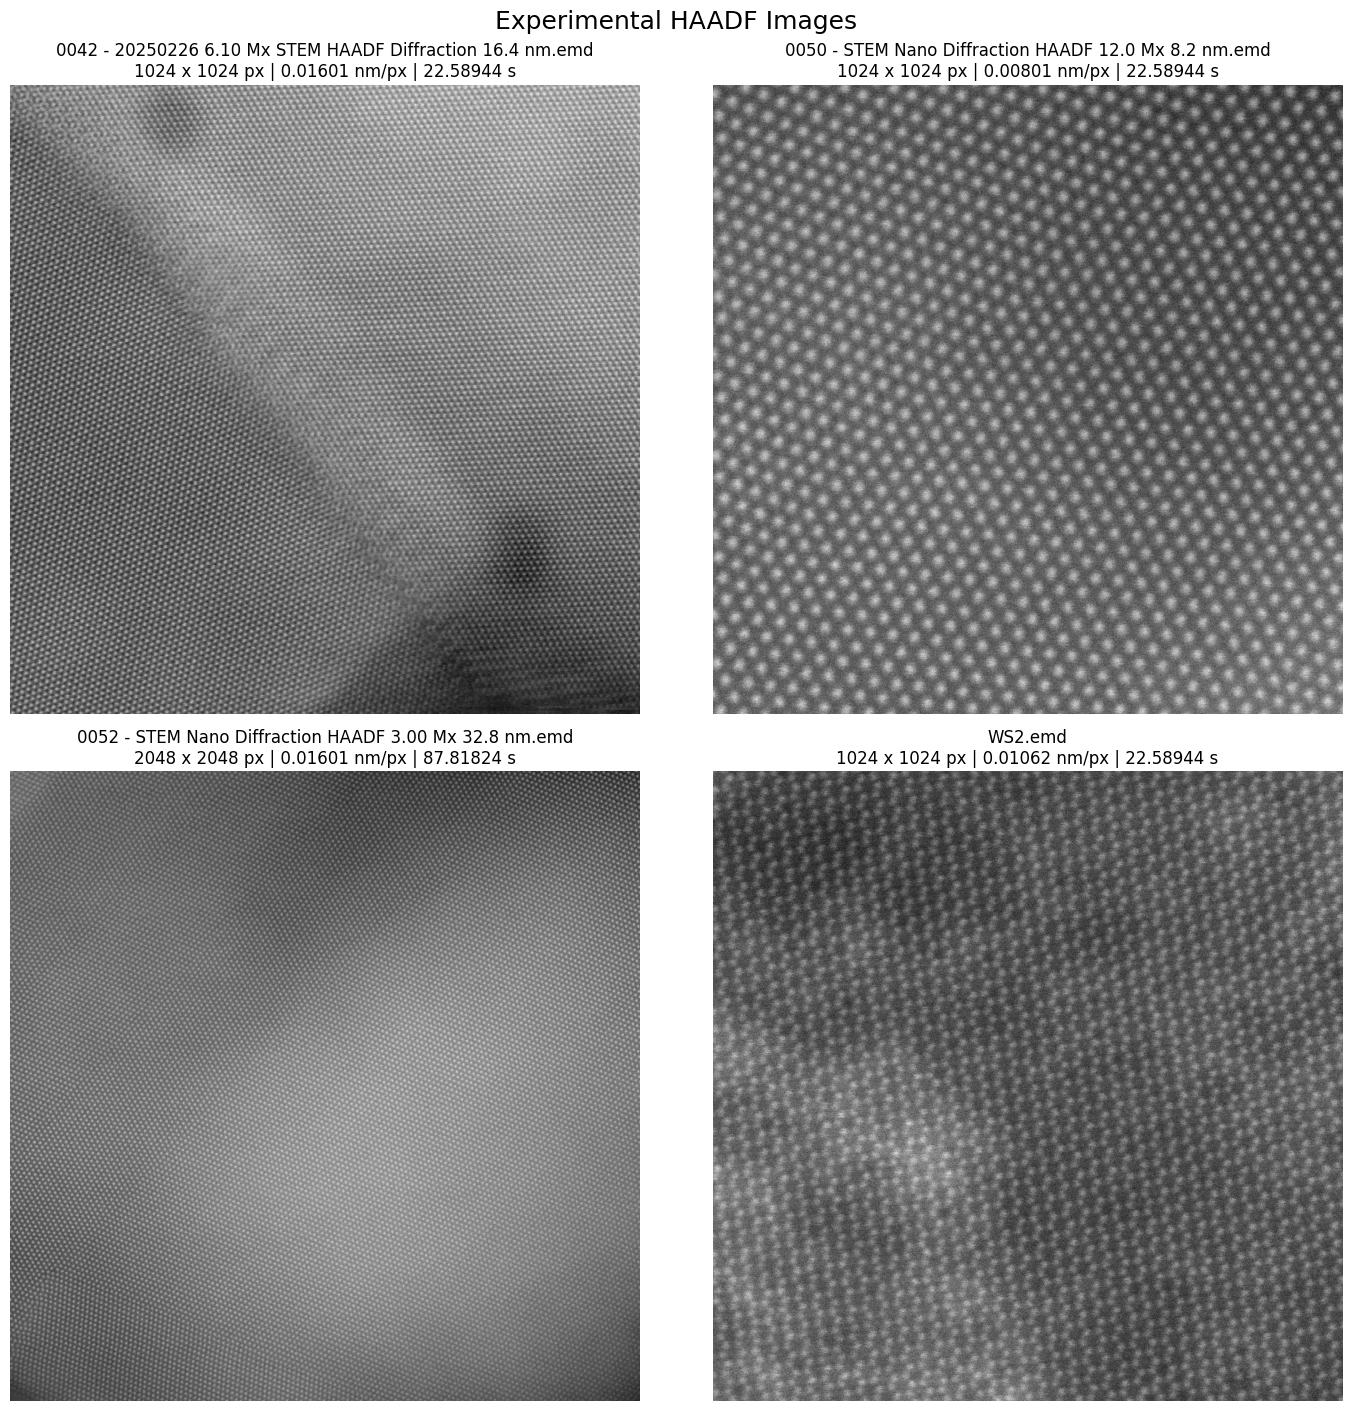

In [4]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 14),
    constrained_layout=True,
)

for axis, (path, haadf, pixel_size_nm, frame_time) in zip(axes.flat, images):
    axis.imshow(np.asarray(haadf), cmap='gray', vmin=0.0, vmax=1.0)
    axis.set_title(
        f'{path.name}\n'
        f'{haadf.shape[1]} x {haadf.shape[0]} px | '
        f'{pixel_size_nm:.5f} nm/px | {frame_time:.5f} s'
    )
    axis.axis('off')

for axis in axes.flat[len(images):]:
    axis.axis('off')

fig.suptitle('Experimental HAADF Images', fontsize=18)
plt.show()